<a href="https://colab.research.google.com/github/Coobaltoo13/milling-tool-life-fusion/blob/main/04_variantes_autoencoder_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variantes de Autoencoder: MLP solo vs LSTM solo vs MLP+LSTM

**Proyecto:** Fusión Multimodal de Vibración y Corriente para Predicción de Vida Útil en Fresado

**Objetivo:** Comparar el rendimiento de tres arquitecturas después del autoencoder:
1. Autoencoder + MLP
2. Autoencoder + LSTM
3. Autoencoder + MLP + LSTM (ya evaluado en notebook 03
)

In [1]:
#Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [4]:
#Cargar datos y preparar
url = 'https://raw.githubusercontent.com/Coobaltoo13/milling-tool-life-fusion/main/data/raw/FeatureAndMetadata_Milling.csv'
df = pd.read_csv(url, sep=';', header=0, decimal=',', skiprows=[1])

# Separar features y etiqueta
X = df.iloc[:, :121].apply(pd.to_numeric, errors='coerce')

# Assuming 'Column131' is the correct target variable for 'CycleToFailureNormalized'
y = pd.to_numeric(df['Column131'], errors='coerce')

# Eliminar columnas completamente vacías
X = X.dropna(axis=1, how='all')

# Imputar valores faltantes con la media
X = X.fillna(X.mean())

# Eliminar filas con NaN en y
mask = ~y.isnull()
X = X[mask].values
y = y[mask].values

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (774, 120)
Test: (194, 120)


In [6]:
#Funciones auxiliares
def build_autoencoder(input_dim, latent_dim):
    encoder_input = layers.Input(shape=(input_dim,))
    x = layers.Dense(64, activation='relu')(encoder_input)
    x = layers.Dense(32, activation='relu')(x)
    latent = layers.Dense(latent_dim, activation='relu', name='latent')(x)
    x = layers.Dense(32, activation='relu')(latent)
    x = layers.Dense(64, activation='relu')(x)
    decoder_output = layers.Dense(input_dim, activation='linear')(x)
    autoencoder = models.Model(encoder_input, decoder_output)
    autoencoder.compile(optimizer='adam', loss='mse')
    encoder = models.Model(encoder_input, latent)
    return autoencoder, encoder

def build_mlp_only(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def build_lstm_only(latent_dim):
    model = models.Sequential([
        layers.Input(shape=(1, latent_dim)),
        layers.LSTM(32, return_sequences=False),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

def calcular_metricas(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    y_true_class = (y_true >= 0.5).astype(int)
    y_pred_class = (y_pred >= 0.5).astype(int)
    f1 = f1_score(y_true_class, y_pred_class, zero_division=0)
    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall = recall_score(y_true_class, y_pred_class, zero_division=0)
    try:
        auc = roc_auc_score(y_true_class, y_pred)
    except:
        auc = np.nan
    return rmse, mae, r2, f1, precision, recall, auc

In [7]:
#Bucle de sensibilidad para variantes
latent_dims = [2, 4, 8, 16, 24, 32, 48, 64, 80]
resultados = []

for dim in latent_dims:
    print(f"\n===== Dimensión latente: {dim} =====")

    # Autoencoder
    ae, encoder = build_autoencoder(X_train_scaled.shape[1], dim)
    ae.fit(X_train_scaled, X_train_scaled, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    X_train_latent = encoder.predict(X_train_scaled, verbose=0)
    X_test_latent = encoder.predict(X_test_scaled, verbose=0)

    # MLP solo
    mlp = build_mlp_only(dim)
    mlp.fit(X_train_latent, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    y_pred_mlp = mlp.predict(X_test_latent, verbose=0).flatten()
    rmse, mae, r2, f1, precision, recall, auc = calcular_metricas(y_test, y_pred_mlp)
    resultados.append({'dim': dim, 'modelo': 'MLP_solo', 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'F1': f1, 'Precision': precision, 'Recall': recall, 'AUC': auc})

    # LSTM solo
    X_train_latent_lstm = X_train_latent.reshape((X_train_latent.shape[0], 1, dim))
    X_test_latent_lstm = X_test_latent.reshape((X_test_latent.shape[0], 1, dim))
    lstm = build_lstm_only(dim)
    lstm.fit(X_train_latent_lstm, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=0)
    y_pred_lstm = lstm.predict(X_test_latent_lstm, verbose=0).flatten()
    rmse, mae, r2, f1, precision, recall, auc = calcular_metricas(y_test, y_pred_lstm)
    resultados.append({'dim': dim, 'modelo': 'LSTM_solo', 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'F1': f1, 'Precision': precision, 'Recall': recall, 'AUC': auc})

df_variantes = pd.DataFrame(resultados)
df_variantes


===== Dimensión latente: 2 =====

===== Dimensión latente: 4 =====



===== Dimensión latente: 8 =====



===== Dimensión latente: 16 =====

===== Dimensión latente: 24 =====

===== Dimensión latente: 32 =====

===== Dimensión latente: 48 =====

===== Dimensión latente: 64 =====

===== Dimensión latente: 80 =====


,dim,modelo,RMSE,MAE,R2,F1,Precision,Recall,AUC
0,2,MLP_solo,0.239076,0.198217,0.345208,0.765550,0.707965,0.833333,0.781356
1,2,LSTM_solo,0.235439,0.190975,0.364977,0.764151,0.698276,0.843750,0.781463
2,4,MLP_solo,0.229022,0.182728,0.399119,0.745098,0.703704,0.791667,0.808780
3,4,LSTM_solo,0.225732,0.176816,0.416261,0.767773,0.704348,0.843750,0.817921
4,8,MLP_solo,0.223522,0.171545,0.427637,0.792453,0.724138,0.875000,0.856824
5,8,LSTM_solo,0.202093,0.158130,0.532120,0.786070,0.752381,0.822917,0.869898
6,16,MLP_solo,0.208329,0.141387,0.502797,0.837696,0.842105,0.833333,0.901361
7,16,LSTM_solo,0.162971,0.125437,0.695735,0.841584,0.801887,0.885417,0.938563
8,24,MLP_solo,0.219056,0.156560,0.450279,0.784946,0.811111,0.760417,0.884885
9,24,LSTM_solo,0.160465,0.122706,0.705019,0.841584,0.801887,0.885417,0.929634


In [8]:
# Resultados del notebook 03 (Autoencoder + MLP + LSTM)
resultados_combinados = [
    {'dim': 48, 'modelo': 'MLP+LSTM', 'RMSE': 0.156361, 'MAE': 0.118645, 'R2': 0.719916, 'F1': 0.854271, 'Precision': 0.825243, 'Recall': 0.885417, 'AUC': 0.929847},
    {'dim': 64, 'modelo': 'MLP+LSTM', 'RMSE': 0.168564, 'MAE': 0.120796, 'R2': 0.674491, 'F1': 0.855615, 'Precision': 0.879121, 'Recall': 0.833333, 'AUC': 0.936012},
]

df_comparacion = pd.concat([df_variantes, pd.DataFrame(resultados_combinados)], ignore_index=True)
df_comparacion

,dim,modelo,RMSE,MAE,R2,F1,Precision,Recall,AUC
0,2,MLP_solo,0.239076,0.198217,0.345208,0.765550,0.707965,0.833333,0.781356
1,2,LSTM_solo,0.235439,0.190975,0.364977,0.764151,0.698276,0.843750,0.781463
2,4,MLP_solo,0.229022,0.182728,0.399119,0.745098,0.703704,0.791667,0.808780
3,4,LSTM_solo,0.225732,0.176816,0.416261,0.767773,0.704348,0.843750,0.817921
4,8,MLP_solo,0.223522,0.171545,0.427637,0.792453,0.724138,0.875000,0.856824
5,8,LSTM_solo,0.202093,0.158130,0.532120,0.786070,0.752381,0.822917,0.869898
6,16,MLP_solo,0.208329,0.141387,0.502797,0.837696,0.842105,0.833333,0.901361
7,16,LSTM_solo,0.162971,0.125437,0.695735,0.841584,0.801887,0.885417,0.938563
8,24,MLP_solo,0.219056,0.156560,0.450279,0.784946,0.811111,0.760417,0.884885
9,24,LSTM_solo,0.160465,0.122706,0.705019,0.841584,0.801887,0.885417,0.929634


In [9]:
#Mejores resultados por variante
for modelo in df_comparacion['modelo'].unique():
    subset = df_comparacion[df_comparacion['modelo'] == modelo]
    best_r2 = subset.loc[subset['R2'].idxmax()]
    best_f1 = subset.loc[subset['F1'].idxmax()]
    best_auc = subset.loc[subset['AUC'].idxmax()]
    print(f"\n===== {modelo} =====")
    print("Mejor R²:\n", best_r2[['dim','R2','RMSE','MAE']])
    print("Mejor F1:\n", best_f1[['dim','F1','Precision','Recall']])
    print("Mejor AUC:\n", best_auc[['dim','AUC']])


===== MLP_solo =====
Mejor R²:
 dim           64
R2      0.633282
RMSE    0.178916
MAE     0.130848
Name: 14, dtype: object
Mejor F1:
 dim                80
F1           0.852941
Precision    0.805556
Recall        0.90625
Name: 16, dtype: object
Mejor AUC:
 dim          64
AUC    0.919111
Name: 14, dtype: object

===== LSTM_solo =====
Mejor R²:
 dim           64
R2      0.784616
RMSE    0.137117
MAE     0.109122
Name: 15, dtype: object
Mejor F1:
 dim               64
F1           0.90625
Precision    0.90625
Recall       0.90625
Name: 15, dtype: object
Mejor AUC:
 dim          64
AUC    0.967368
Name: 15, dtype: object

===== MLP+LSTM =====
Mejor R²:
 dim           48
R2      0.719916
RMSE    0.156361
MAE     0.118645
Name: 18, dtype: object
Mejor F1:
 dim                64
F1           0.855615
Precision    0.879121
Recall       0.833333
Name: 19, dtype: object
Mejor AUC:
 dim          64
AUC    0.936012
Name: 19, dtype: object


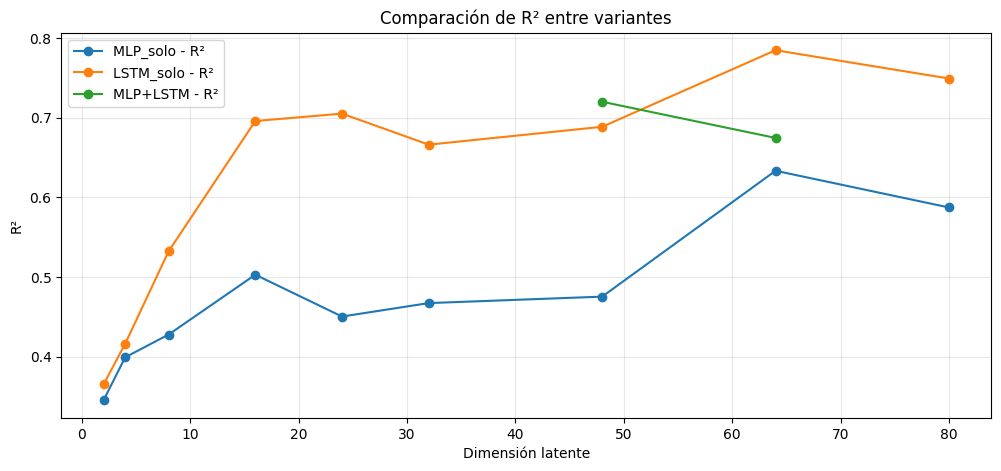

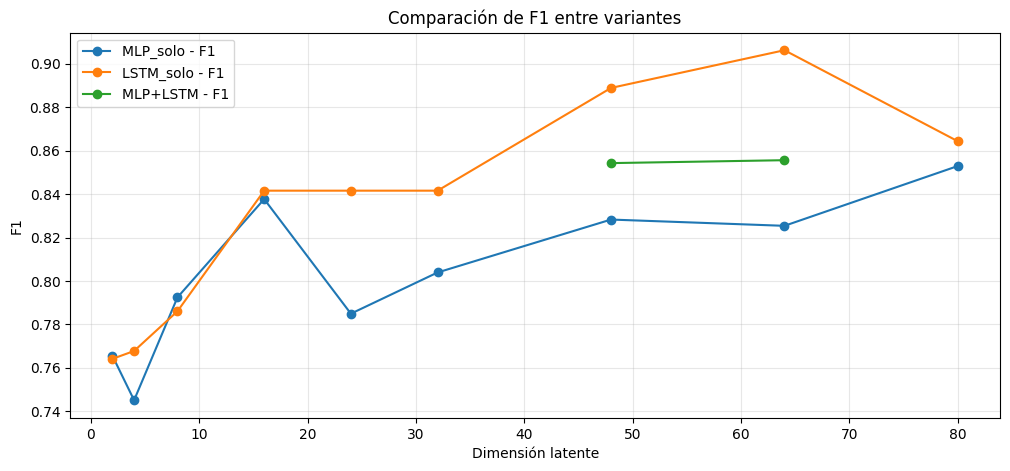

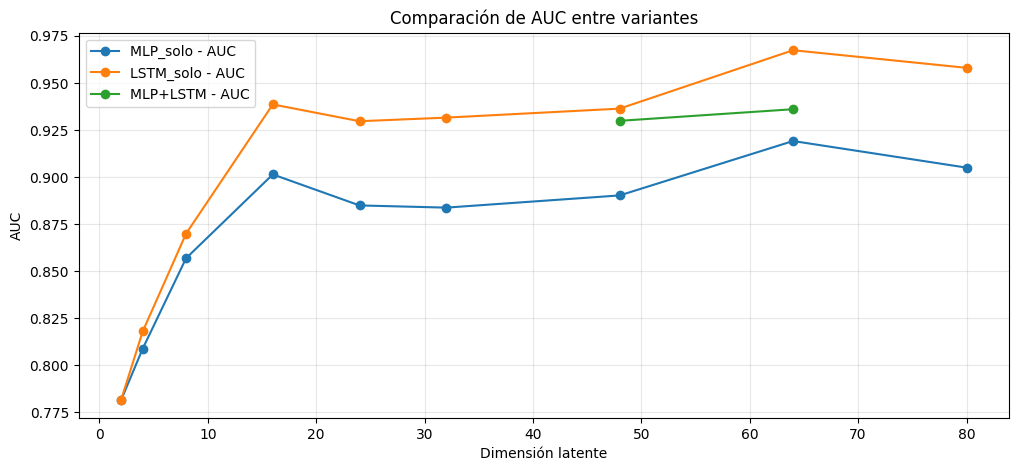

In [11]:
#Graficas Comparativas
plt.figure(figsize=(12, 5))
for modelo in df_comparacion['modelo'].unique():
    subset = df_comparacion[df_comparacion['modelo'] == modelo]
    plt.plot(subset['dim'], subset['R2'], marker='o', label=f'{modelo} - R²')
plt.xlabel('Dimensión latente')
plt.ylabel('R²')
plt.title('Comparación de R² entre variantes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
for modelo in df_comparacion['modelo'].unique():
    subset = df_comparacion[df_comparacion['modelo'] == modelo]
    plt.plot(subset['dim'], subset['F1'], marker='o', label=f'{modelo} - F1')
plt.xlabel('Dimensión latente')
plt.ylabel('F1')
plt.title('Comparación de F1 entre variantes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
for modelo in df_comparacion['modelo'].unique():
    subset = df_comparacion[df_comparacion['modelo'] == modelo]
    plt.plot(subset['dim'], subset['AUC'], marker='o', label=f'{modelo} - AUC')
plt.xlabel('Dimensión latente')
plt.ylabel('AUC')
plt.title('Comparación de AUC entre variantes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusión

Se compararon tres variantes de arquitectura después del autoencoder: MLP solo, LSTM solo y MLP+LSTM. Los resultados en el conjunto de prueba fueron:

| Variante | Mejor dim | R² | RMSE | MAE | F1 | AUC |
|:---|:---|:---|:---|:---|:---|:---|
| MLP_solo | 64 | 0.6333 | 0.1789 | 0.1308 | 0.8529 | 0.9191 |
| MLP+LSTM | 48 | 0.7199 | 0.1564 | 0.1186 | 0.8543 | 0.9298 |
| **LSTM_solo** | **64** | **0.7846** | **0.1371** | **0.1091** | **0.9063** | **0.9674** |

**Hallazgos principales:**

1. **El LSTM solo con dimensión 64 supera a las otras dos variantes en todas las métricas.** Obtiene el mejor R² (0.7846), el menor error (RMSE = 0.1371, MAE = 0.1091) y la mejor clasificación (F1 = 0.9063, AUC = 0.9674).

2. **La combinación MLP+LSTM no aporta mejoras.** Añadir un MLP antes del LSTM procesa los datos innecesariamente y reduce el rendimiento en comparación con el LSTM solo.

3. **El MLP solo es la variante con peor rendimiento.** Confirma que la temporalidad de las señales es relevante y que el LSTM captura mejor esa información.

4. **La dimensión óptima para el LSTM solo es 64**, que coincide con la mejor dimensión para clasificación en el análisis de sensibilidad anterior.

**Conclusión:** La mejor configuración es **Autoencoder (dim=64) + LSTM solo**, que será refinada en el siguiente notebook con dropout y early stopping.